DIAZ BARRON GROVER ALEJANDRO

1. Atenúa el ruido en la imagen ruido.jpg tal cual se ve en el ejemplo: 

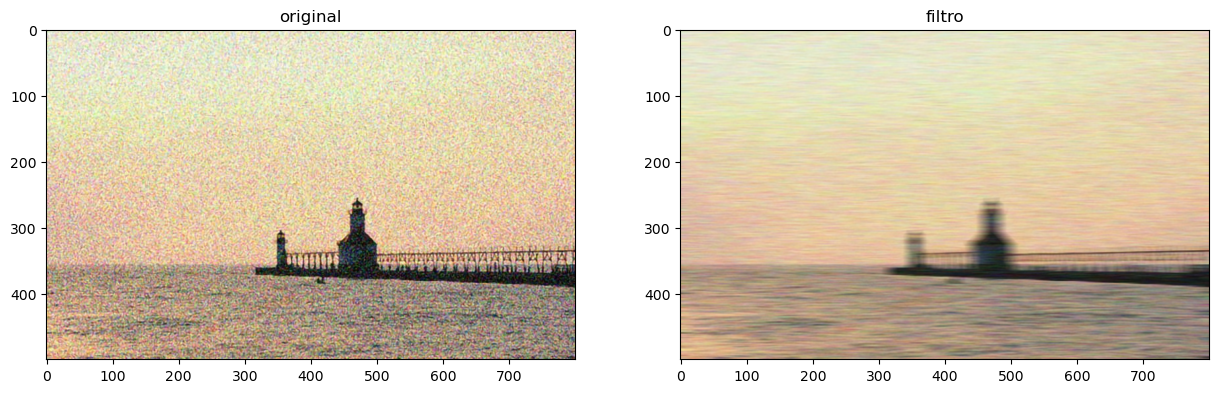

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def convolucion_media_horizontal(imagen,tama_kernel):
    kernel=np.ones((1,tama_kernel),np.float32)/tama_kernel
    img_final=cv2.filter2D(imagen,-1,kernel)
    return img_final
img=cv2.imread(r'ruido.jpg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)


imgrest_r=convolucion_media_horizontal(img_rgb[:,:,0],25)
imgrest_g=convolucion_media_horizontal(img_rgb[:,:,1],25)
imgrest_b=convolucion_media_horizontal(img_rgb[:,:,2],25)

img_color=np.stack([imgrest_r,imgrest_g,imgrest_b],axis=2)



plt.figure(figsize=(15,5))
plt.subplot(121)
plt.title("original")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.title("filtro")
plt.imshow(img_color)

plt.show()

2.  Usando la imagen “rosa.png” obtenga el siguiente resultado: 

3. sando la imagen “Elementos jpg” obtenga el siguiente resultado. 

4. Usando la imagen Cristo obtiene el siguiente resultado (utiliza máscaras de 
convolución) 

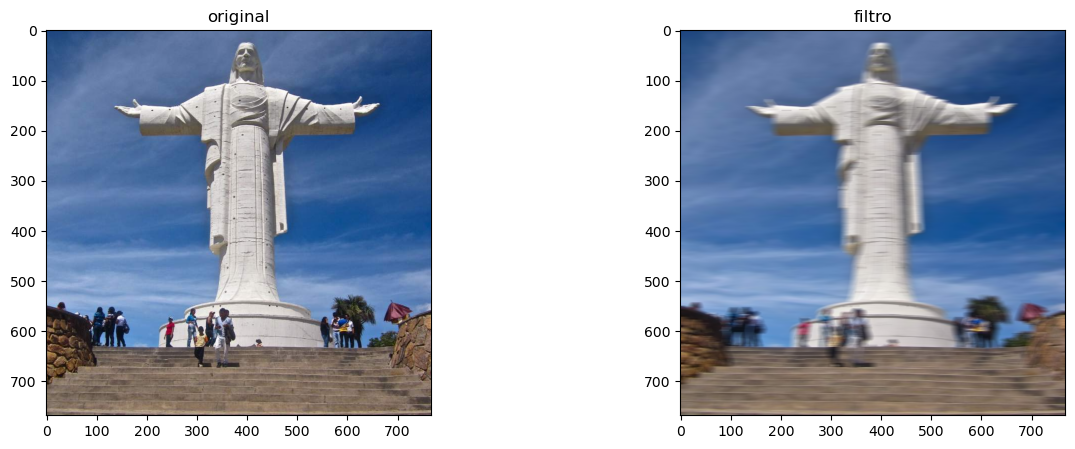

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def convolucion_media_horizontal(imagen,tama_kernel):
    kernel=np.ones((1,tama_kernel),np.float32)/tama_kernel
    img_final=cv2.filter2D(imagen,-1,kernel)
    return img_final
img=cv2.imread(r'cristo.jpg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)


imgrest_r=convolucion_media_horizontal(img_rgb[:,:,0],25)
imgrest_g=convolucion_media_horizontal(img_rgb[:,:,1],25)
imgrest_b=convolucion_media_horizontal(img_rgb[:,:,2],25)

img_color=np.stack([imgrest_r,imgrest_g,imgrest_b],axis=2)



plt.figure(figsize=(15,5))
plt.subplot(121)
plt.title("original")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.title("filtro")
plt.imshow(img_color)

plt.show()

5. Realiza una combinación de técnicas con una fotografía tuya (utiliza las técnicas de 
bordes) explica las diferencias 

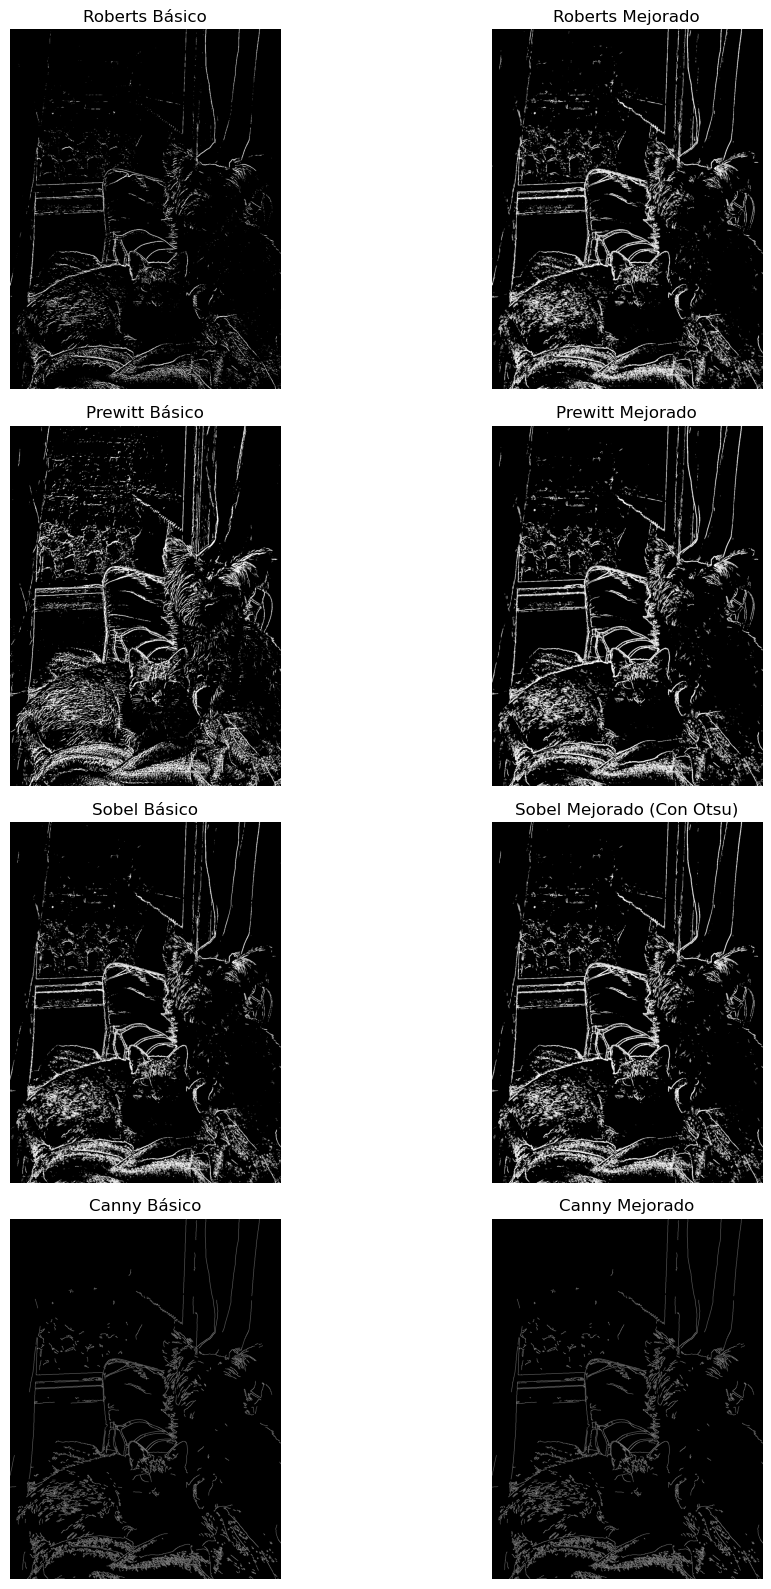

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt




def roberts_basic(imagen, umbral_val=30):
    # Convertir la imagen a escala de grises
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Definir kernels de Roberts básicos
    kernelX = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    kernelY = np.array([[0, -1], [1, 0]], dtype=np.float32)
    # Aplicar convolución sin suavizado previo
    robX = cv2.filter2D(img_gray, -1, kernelX)
    robY = cv2.filter2D(img_gray, -1, kernelY)
    # Calcular la magnitud del gradiente (corrigiendo la fórmula)
    magnitud = np.sqrt(robX.astype(np.float32)**2 + robY.astype(np.float32)**2)
    # Normalizar al rango 0-255
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Umbralizar la imagen para obtener bordes binarios
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def prewitt_basic(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    # Definir kernels Prewitt para X y Y
    kernelX = np.array([[1, 0, -1],
                        [1, 0, -1],
                        [1, 0, -1]], dtype=np.float32)
    kernelY = np.array([[1, 1, 1],
                        [0, 0, 0],
                        [-1, -1, -1]], dtype=np.float32)
    gradX = cv2.filter2D(img_gray, -1, kernelX)
    gradY = cv2.filter2D(img_gray, -1, kernelY)
    magnitud = np.sqrt(gradX.astype(np.float32)**2 + gradY.astype(np.float32)**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def sobel_basic(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    sobX = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobY = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitud = np.sqrt(sobX**2 + sobY**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def canny_basic(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    return cv2.Canny(suavizado, 100, 200)


#  Funciones Mejoradas


def roberts_mejorado(imagen, umbral_val=30, weight=0.7):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    kernelX = np.array([[-2, 0], [0, 2]], dtype=np.float32)
    kernelY = np.array([[0, 2], [-2, 0]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizado, cv2.CV_16S, kernelX)
    grad_y = cv2.filter2D(suavizado, cv2.CV_16S, kernelY)
    abs_x = cv2.convertScaleAbs(grad_x)
    abs_y = cv2.convertScaleAbs(grad_y)
    roberts_improved = cv2.addWeighted(abs_x, weight, abs_y, weight, 0)
    _, bordes = cv2.threshold(roberts_improved, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def prewitt_mejor(imagen, umbral_val=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    kernelX = np.array([[3, 0, -3],
                        [3, 0, -3],
                        [3, 0, -3]], dtype=np.float32)
    kernelY = np.array([[3, 3, 3],
                        [0, 0, 0],
                        [-3, -3, -3]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizado, cv2.CV_64F, kernelX)
    grad_y = cv2.filter2D(suavizado, cv2.CV_64F, kernelY)
    magnitud = np.sqrt(grad_x**2 + grad_y**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX)
    magnitud_norm = magnitud_norm.astype(np.uint8)
    _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def sobel_mejorado(imagen, tam_kernel=3, umbral_val=30, usar_otsu=True):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    sobelX = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
    sobelY = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
    magnitud = np.sqrt(sobelX**2 + sobelY**2)
    magnitud_norm = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX)
    magnitud_norm = magnitud_norm.astype(np.uint8)
    if usar_otsu:
        _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, bordes = cv2.threshold(magnitud_norm, umbral_val, 255, cv2.THRESH_BINARY)
    return bordes

def canny_mejorado(imagen):
    # En esta versión podemos considerar un suavizado adicional
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
    return cv2.Canny(suavizado, 100, 200)


# Leer imagen
img = cv2.imread('imagentango.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Obtener resultados básicos
roberts_basic_res = roberts_basic(img, umbral_val=30)
prewitt_basic_res = prewitt_basic(img, umbral_val=30)
sobel_basic_res = sobel_basic(img, umbral_val=30)
canny_basic_res = canny_basic(img)

# Obtener resultados mejorados
roberts_mej_res = roberts_mejorado(img, umbral_val=30, weight=0.7)
prewitt_mej_res = prewitt_mejor(img, umbral_val=30)
sobel_mej_res = sobel_mejorado(img, tam_kernel=3, umbral_val=30, usar_otsu=True)
canny_mej_res = canny_mejorado(img)  # Para Canny, usamos la misma función en ambas versiones

# Crear una figura con comparación: 4 filas (Roberts, Prewitt, Sobel, Canny) y 2 columnas (Básico vs Mejorado)
plt.figure(figsize=(12, 16))

# Roberts
plt.subplot(4, 2, 1)
plt.imshow(roberts_basic_res, cmap='gray')
plt.title("Roberts Básico")
plt.axis("off")

plt.subplot(4, 2, 2)
plt.imshow(roberts_mej_res, cmap='gray')
plt.title("Roberts Mejorado")
plt.axis("off")

# Prewitt
plt.subplot(4, 2, 3)
plt.imshow(prewitt_basic_res, cmap='gray')
plt.title("Prewitt Básico")
plt.axis("off")

plt.subplot(4, 2, 4)
plt.imshow(prewitt_mej_res, cmap='gray')
plt.title("Prewitt Mejorado")
plt.axis("off")

# Sobel
plt.subplot(4, 2, 5)
plt.imshow(sobel_basic_res, cmap='gray')
plt.title("Sobel Básico")
plt.axis("off")

plt.subplot(4, 2, 6)
plt.imshow(sobel_mej_res, cmap='gray')
plt.title("Sobel Mejorado (Con Otsu)")
plt.axis("off")

# Canny
plt.subplot(4, 2, 7)
plt.imshow(canny_basic_res, cmap='gray')
plt.title("Canny Básico")
plt.axis("off")

plt.subplot(4, 2, 8)
plt.imshow(canny_mej_res, cmap='gray')
plt.title("Canny Mejorado")
plt.axis("off")

plt.tight_layout()
plt.show()


explicacion bordes:

Roberts Básico:

Aplica los kernels de Roberts directamente sobre la imagen en escala de grises sin ningún tipo de suavizado previo.
Los kernels de Roberts son muy pequeños (2×2) y sensibles al ruido.

Roberts Mejorado:
Introduce un paso de suavizado Gaussiano antes de aplicar los kernels de Roberts. Esto ayuda a reducir el ruido en la imagen, lo que a su vez puede llevar a una detección de bordes más limpia.


Prewitt Básico:

Aplica los kernels de Prewitt directamente sobre la imagen en escala de grises sin suavizado previo.
Los kernels de Prewitt (3×3) están diseñados para estimar las derivadas primera en las direcciones horizontal y vertical. 

Prewitt Mejorado:

Introduce un paso de suavizado Gaussiano para reducir el ruido antes de la aplicación de los kernels.
Modifica los valores de los kernels, utilizando ±3 en lugar de ±1. Esto amplifica la respuesta a los cambios de intensidad, lo que podría resultar en bordes más definidos en ciertas situaciones.



Sobel Básico:

Aplica los operadores de Sobel directamente a la imagen en escala de grises sin un suavizado explícito en la función. Sin embargo, internamente, el operador Sobel con un tamaño de kernel mayor que 1 realiza una forma de suavizado. En tu código, usas un kernel de tamaño 3×3.

Sobel Mejorado:

Introduce un paso de suavizado Gaussiano explícito antes de aplicar los operadores de Sobel. Esto proporciona una reducción de ruido más controlada.


Canny Básico:

Aplica un suavizado Gaussiano como primer paso integral del algoritmo Canny.
Calcula la magnitud y la dirección del gradiente utilizando operadores similares a Sobel.


6. Realiza el código del lapaciano y lapaciano del gausiano mejorando los bordes 
(deben verse más nítidos los bordes encontrados ) 

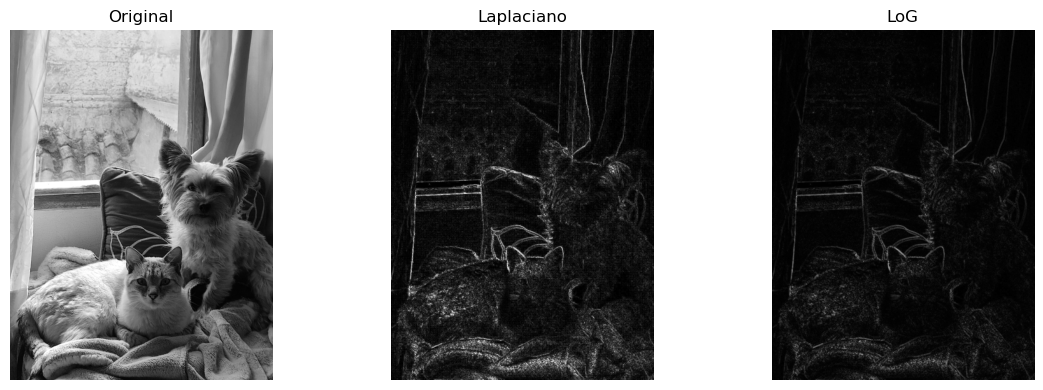

In [2]:
import cv2
import matplotlib.pyplot as plt


img = cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)


# Aplicar Laplaciano puro
lap = cv2.Laplacian(img, ddepth=cv2.CV_64F, ksize=3)
lap = cv2.convertScaleAbs(lap)  # pasa a 0–255

# Aplica LoG: suavizado + Laplaciano
blur = cv2.GaussianBlur(img, ksize=(5,5), sigmaX=1.0)
log  = cv2.Laplacian(blur, ddepth=cv2.CV_64F, ksize=3)
log  = cv2.convertScaleAbs(log)

# mostrar resultados
titles = ['Original', 'Laplaciano', 'LoG']
images = [img, lap, log]

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate(zip(images, titles), 1):
    ax = plt.subplot(1, 3, i)
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()